In [81]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)
##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path



Not on GPU


In [82]:
use_gpu=False
sum_kwargs = {
            "pad_output": True}
waveform_derivative = StableEMRIDerivative(waveform_class=SuperKludgeWaveform,sum_kwargs=sum_kwargs,\
                                           mode_selector_kwargs=dict(mode_selection_threshold=1e-5), 
                                          inspiral_kwargs=dict(err=1e-11, max_iter=10000))

In [56]:
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.01
xI0 = 1.0
dist = 0.8
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = np.pi/4
Phi_theta0 = 0.0
Phi_r0 = 0.0
dt = 10.0
T = 0.1
chi2 = 0.6

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=False
p0=9.0
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
param_names = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev_0_p","dev_0_e","dev_1_p","dev_1_e","dev_2_p","dev_2_e"]

In [70]:
parameters = {}
for i in range(len(param_names)):
    parameters[param_names[i]] = pars_list[i]

param_to_vary = 'xI0'

delta = 1e-5  #finite difference delta for the chosen paramete
order = 4 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative

der = waveform_derivative(T = T, dt = dt, 
                    parameters = parameters, 
                    param_to_vary = param_to_vary,
                    delta = delta,
                    order = order,
                    kind = kind,
                    )

if use_gpu:
    der = der.get()


ValueError: Interpolation: x out of bounds. Must be either 1 or -1.

0


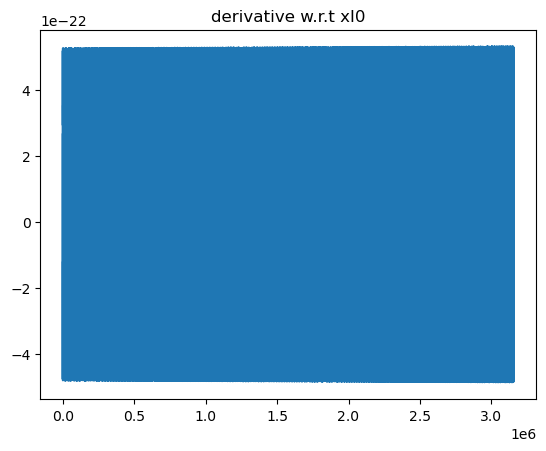

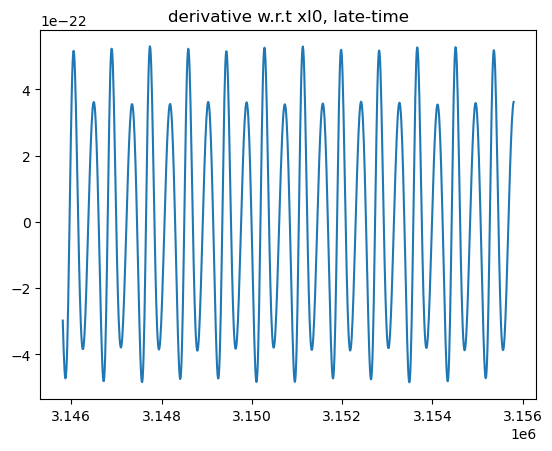

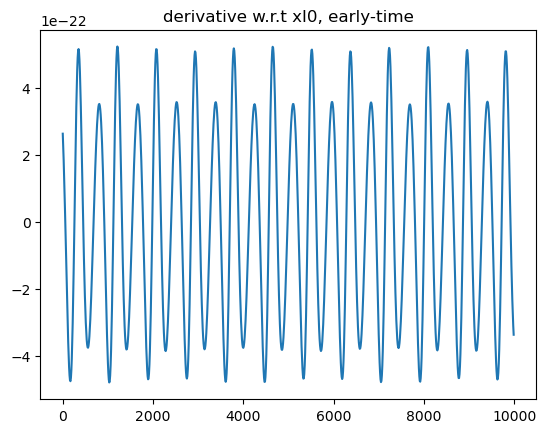

In [71]:
Npad = waveform_derivative.cache['Npad']

print(Npad)

if Npad == 0:
    Npad = 1
    
times = np.arange(len(der))*dt
plt.plot(times, der.real)
plt.title(f"derivative w.r.t {param_to_vary}")
plt.show()

times = np.arange(len(der))*dt
plt.plot(times[-Npad - 1000: - Npad], der.real[-Npad - 1000: -Npad])
plt.title(f"derivative w.r.t {param_to_vary}, late-time")
plt.show()

plt.plot(times[:1000], der.real[:1000])
plt.title(f"derivative w.r.t {param_to_vary}, early-time")
plt.show()

In [72]:
sum_kwargs = {
            "pad_output": True}
wave_gen_base = GenerateEMRIWaveform(SuperKludgeWaveform,
    sum_kwargs=sum_kwargs,\
    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),\
    inspiral_kwargs=dict(err=1e-11, max_iter=10000))

In [73]:
parameters['Phi_phi0']

0.7853981633974483

In [74]:
# compute the derivative manually
wavdelts = []
xp = waveform_derivative.xp

for delta in waveform_derivative.deltas:
    parameters_in = parameters.copy()
    parameters_in[param_to_vary] += delta
    
    add_args = [parameters_in['chi2'], parameters_in['evolve_1PA'], parameters_in["evolve_primary"],\
                 parameters_in['evolve_2PA'],parameters_in['deviation_included'],parameters_in['dev_0_p'],\
                    parameters_in['dev_0_e'],parameters_in['dev_1_p'],parameters_in['dev_1_e'],\
                        parameters_in['dev_2_p'],parameters_in['dev_2_e']]
    
    wave = wave_gen_base(
        parameters_in['m1'],
        parameters_in['m2'],
        parameters_in['a'],
        parameters_in['p0'],
        parameters_in['e0'],
        parameters_in['xI0'],
        parameters_in['dist'],
        parameters_in['qS'],
        parameters_in['phiS'],
        parameters_in['qK'],
        parameters_in['phiK'],
        parameters_in['Phi_phi0'],
        parameters_in['Phi_theta0'],
        parameters_in['Phi_r0'],
        *add_args,
        dt=dt, 
        T=T,
        
    )
    wave = xp.concatenate((wave[:-Npad],xp.zeros(Npad)), dtype = wave.dtype)
    wavdelts.append(wave)
wavdelts = xp.asarray(wavdelts) 
deriv_man = waveform_derivative._stencil(wavdelts, waveform_derivative.delta, waveform_derivative.order, waveform_derivative.kind)
if use_gpu:
    deriv_man = deriv_man.get()

plt.plot(times[:2000], der.real[0:2000],color="red")
plt.plot(times[:2000], deriv_man.real[0:2000], '--')
plt.show()

plt.plot(times[:2000], der.imag[0:2000],color="red")
plt.plot(times[:2000], deriv_man.imag[0:2000], '--')
plt.show()

plt.plot(der.real[20000:20500],color="red")
plt.plot(deriv_man.real[20000:20500], '--')
plt.show()

ValueError: Only xI = 1 is supported.

In [ ]:
from stableemrifisher.utils import inner_product, generate_PSD, padding
from tqdm import tqdm
parameters_in['deviation_included']=False
add_args = [parameters_in['chi2'], parameters_in['evolve_1PA'], parameters_in["evolve_primary"],\
                 parameters_in['evolve_2PA'],parameters_in['deviation_included'],parameters_in['dev_0_p'],\
                    parameters_in['dev_0_e'],parameters_in['dev_1_p'],parameters_in['dev_1_e'],\
                        parameters_in['dev_2_p'],parameters_in['dev_2_e']]
wave = wave_gen_base(
        parameters_in['m1'],
        parameters_in['m2'],
        parameters_in['a'],
        parameters_in['p0'],
        parameters_in['e0'],
        parameters_in['xI0'],
        parameters_in['dist'],
        parameters_in['qS'],
        parameters_in['phiS'],
        parameters_in['qK'],
        parameters_in['phiK'],
        parameters_in['Phi_phi0'],
        parameters_in['Phi_theta0'],
        parameters_in['Phi_r0'],
        *add_args,
        dt=dt, 
        T=T,
    )

wave = xp.concatenate((wave[:-Npad], xp.zeros(Npad)), dtype = wave.dtype)

wave_list = [wave.real, -wave.imag]
PSD = generate_PSD(wave_list, dt=dt, use_gpu=use_gpu)

In [ ]:
Npad

1

In [75]:
def Fisher_1D(partialh):
    return inner_product(partialh, partialh, PSD = PSD, dt = dt)

der_list = [der.real, -der.imag]
F1D = Fisher_1D(der_list)
sigma1D = 1/np.sqrt(F1D)
print(f"sigma {param_to_vary}: ", sigma1D)

sigma xI0:  0.0009251191469880002


In [76]:
param_to_vary

'xI0'

In [77]:

def likelihood(h_inj, h_temp):
    delta = h_inj - h_temp
    delta = [delta.real, -delta.imag]
    return np.exp(-0.5 * inner_product(delta, delta, PSD = PSD, dt = dt, use_gpu=use_gpu))

N = 50

param_to_vary_range = np.linspace(parameters[param_to_vary] - 4 * sigma1D, parameters[param_to_vary] + 4 * sigma1D, N)

likes = []

for i in tqdm(range(N)):
    parameters_in = parameters.copy()
    parameters_in[param_to_vary] = param_to_vary_range[i]
    add_args = [parameters_in['chi2'], parameters_in['evolve_1PA'], parameters_in["evolve_primary"],\
                 parameters_in['evolve_2PA'],parameters_in['deviation_included'],parameters_in['dev_0_p'],\
                    parameters_in['dev_0_e'],parameters_in['dev_1_p'],parameters_in['dev_1_e'],\
                        parameters_in['dev_2_p'],parameters_in['dev_2_e']]
    htemp = wave_gen_base(
        parameters_in['m1'],
        parameters_in['m2'],
        parameters_in['a'],
        parameters_in['p0'],
        parameters_in['e0'],
        parameters_in['xI0'],
        parameters_in['dist'],
        parameters_in['qS'],
        parameters_in['phiS'],
        parameters_in['qK'],
        parameters_in['phiK'],
        parameters_in['Phi_phi0'],
        parameters_in['Phi_theta0'],
        parameters_in['Phi_r0'],
        *add_args,
        dt=dt, 
        T=T,
    )

    htemp = xp.concatenate((htemp[:-Npad], xp.zeros(Npad)), dtype = htemp.dtype)
    likes.append(likelihood(wave, htemp))



  0%|          | 0/50 [00:00<?, ?it/s]


ValueError: Only xI = 1 is supported.

In [78]:
param_to_vary_range

array([0.99629952, 0.99645056, 0.9966016 , 0.99675264, 0.99690368,
       0.99705472, 0.99720576, 0.9973568 , 0.99750784, 0.99765888,
       0.99780992, 0.99796096, 0.998112  , 0.99826304, 0.99841408,
       0.99856512, 0.99871616, 0.9988672 , 0.99901824, 0.99916928,
       0.99932032, 0.99947136, 0.9996224 , 0.99977344, 0.99992448,
       1.00007552, 1.00022656, 1.0003776 , 1.00052864, 1.00067968,
       1.00083072, 1.00098176, 1.0011328 , 1.00128384, 1.00143488,
       1.00158592, 1.00173696, 1.001888  , 1.00203904, 1.00219008,
       1.00234112, 1.00249216, 1.0026432 , 1.00279424, 1.00294528,
       1.00309632, 1.00324736, 1.0033984 , 1.00354944, 1.00370048])

In [79]:
wave.shape, der.shape

((315582,), (315582,))

ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

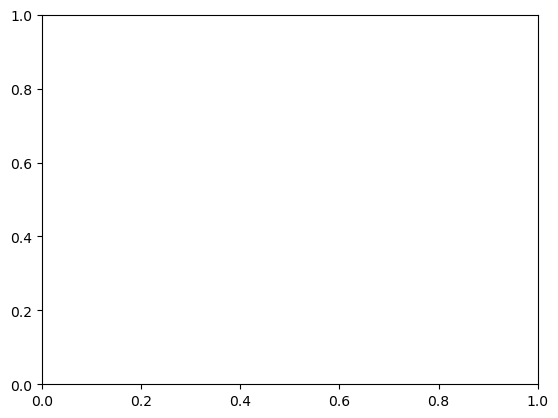

In [80]:
from scipy.stats import norm
normal_approx = norm.pdf(param_to_vary_range, loc = parameters[param_to_vary], scale = sigma1D)
normal_approx /= np.sum(normal_approx)
plt.plot(param_to_vary_range, likes/np.sum(likes), c='k', label='truth')
plt.plot(param_to_vary_range, normal_approx, c='r', label='normal approx', linestyle='--')
plt.legend()
plt.ylabel(r'$\mathcal{L}$')
plt.xlabel(param_to_vary)
plt.savefig(f'1D_like_vs_NA_{param_to_vary}.png', dpi = 300, bbox_inches='tight')
plt.show()

